In [11]:
!pip install -U langchain langchain-openai langchain-google-genai langchain-openrouter python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.8/68.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.4/396.4 kB 18.6 MB/s eta 0:00:00


In [12]:
import os
import json
from dotenv import load_dotenv

load_dotenv(".env")

# WRONG previously:
# os.environ["GOOGLE_API_KEY"] = os.getenv("GEMINI")

# CORRECT:
google_key = os.getenv("GEMINI")
openrouter_key = os.getenv("OPEN_ROUTER")

os.environ["GOOGLE_API_KEY"] = google_key
os.environ["OPENROUTER_API_KEY"] = openrouter_key

In [13]:
import langchain
langchain.__version__

'1.3.4'

In [14]:
# creating a sample agent
from langchain.agents import create_agent

def get_location(location: str) -> str:
    """Get current location."""
    return f"The {location} is amazing"

def get_weather(location: str) -> str:
    """Get weather for a location."""
    return f"The weather in {location} is sunny"

agent = create_agent(
    model="openrouter:openai/gpt-oss-120b:free",
    tools=[get_weather,get_location]
)

response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "what is weather in delhi"
            }
        ]
    }
)

In [15]:
print(json.dumps(response, indent=2, default=str))

{
  "messages": [
    "content='what is weather in delhi' additional_kwargs={} response_metadata={} id='5c34cdaf-c965-46d9-b415-c915328fdf4c'",
    "content='' additional_kwargs={'reasoning_content': 'Need to get weather. Use function.', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'Need to get weather. Use function.'}]} response_metadata={'model_name': 'openai/gpt-oss-120b:free', 'id': 'gen-1780829060-BFSmdloMcWp7atQVHhF4', 'created': 1780829060, 'object': 'chat.completion', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'openrouter'} id='lc_run--019ea1ae-fa53-7e81-9fef-164a500699c6-0' tool_calls=[{'name': 'get_weather', 'args': {'location': 'Delhi'}, 'id': 'chatcmpl-tool-a528c54f1bd3acc1', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 144, 'output_tokens': 36, 'total_tokens': 180, 'input_token_details': {'cache_read': 64, 'cache_creation': 0}, 'output_token_details': {'reasoning': 9}}",
   

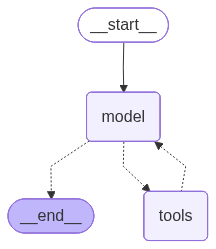

In [16]:
agent

In [17]:
from langchain_openrouter import ChatOpenRouter
from langchain_google_genai import ChatGoogleGenerativeAI

In [18]:
gemini_model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash"
)

# response = gemini_model.invoke("hello")
# print(response.content)

responses = gemini_model.batch(
    [
        "What is AI?",
    ],
    config = {
        'max_concurrency': 3
    }
)

for res in responses:
    print(res.content)

**Artificial Intelligence (AI)** is a broad field of computer science that aims to create machines that can perform tasks that typically require human intelligence. In essence, it's about developing computer systems that can simulate, mimic, and automate human cognitive functions like learning, problem-solving, decision-making, understanding language, and recognizing patterns.

Here's a breakdown of what AI entails:

### What AI Aims to Do:

*   **Learning:** Acquire information and rules for using the information (e.g., from data, experience).
*   **Reasoning:** Use rules to reach approximate or definite conclusions.
*   **Problem-solving:** Apply learned knowledge to solve specific problems.
*   **Perception:** Process sensory input (like images, sounds, speech) to understand the environment.
*   **Language Understanding:** Comprehend and generate human language.
*   **Knowledge Representation:** Store and retrieve information effectively.

### How AI Works (Key Technologies):

AI is

In [19]:
openrouter_model = ChatOpenRouter(
    model="openai/gpt-oss-120b:free"
)

# response = openrouter_model.invoke("hello")
# print(response.content)

# responses = openrouter_model.batch(
#     [
#         "What is AI?",
#         "What is Machine Learning?",
#         "What is Deep Learning?",
#         "What is ML?",
#         "What is RI Learning?",
#         "What is Hybrid Learning?",
#     ],
#     config = {
#         'max_concurrency': 3,
#     }
# )

# for res in responses:
#     print(res.content)

# for chunk in openrouter_model.stream("Why do parrots have colorful feathers tell in 100?"):
#     print(chunk.text, end="", flush=True)

# openrouter_model.invoke("What is full form of ml ?")

In [20]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model

@tool
def get_weather(location:str)->str:
    """Get the weather at a location"""
    return f"It's sunny in {location}"

model = init_chat_model("openrouter:openai/gpt-oss-120b:free")

# response = model.invoke("Why do parrots talk?")
# response


response = model.bind_tools([get_weather]).invoke("What's the weather like in Boston?")
print(response)

for tool_call in response.tool_calls:
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")

content='' additional_kwargs={'reasoning_content': 'Need to call function.', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'Need to call function.'}]} response_metadata={'model_name': 'openai/gpt-oss-120b:free', 'id': 'gen-1780829083-jRYx1Cf5OD4N1jlxxp6Y', 'created': 1780829083, 'object': 'chat.completion', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'openrouter'} id='lc_run--019ea1af-564c-7e51-90fa-7495a8458adb-0' tool_calls=[{'name': 'get_weather', 'args': {'location': 'Boston'}, 'id': 'chatcmpl-tool-8de5236f38341672', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 127, 'output_tokens': 33, 'total_tokens': 160, 'input_token_details': {'cache_read': 64, 'cache_creation': 0}, 'output_token_details': {'reasoning': 6}}
Tool: get_weather
Args: {'location': 'Boston'}


In [21]:
from langchain.messages import SystemMessage, HumanMessage, AIMessage

messages=[
    SystemMessage("You are a CSE expert"),
    HumanMessage("Write 2 lines on artificial intelligence"),
    AIMessage("Hi how are you ?")
]

response=model.invoke(messages)
response.content

'Artificial intelligence enables machines to learn from data, recognize patterns, and make decisions that mimic human cognition.  \nIt powers everything from voice assistants and recommendation engines to autonomous vehicles and advanced scientific research.'

In [22]:
from typing_extensions import TypedDict

class UserDict(TypedDict):
    name: str
    age: int

# user: UserDict = {
#     "name": "Krishna",
#     "age": 22
# }

# print(user)

user: UserDict = {
    "name": "Krishna",
    "age": "twenty two"
}

print(user)

{'name': 'Krishna', 'age': 'twenty two'}


In [23]:
from pydantic import BaseModel

class User(BaseModel):
    name: str
    age: int

user = User(
    name="Krishna",
    age="22"
)

print(user)

name='Krishna' age=22


In [24]:
# Error
# from pydantic import BaseModel

# class User(BaseModel):
#     age: int

# User(age="hello")

In [46]:
from langchain_google_genai import ChatGoogleGenerativeAI

open_router_model = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash",
)

In [47]:
from pydantic import BaseModel, Field

class Movie(BaseModel):
    title: str = Field(description="Movie title")
    year: int = Field(description="Release year")
    director: str = Field(description="Movie director")
    rating: float = Field(description="Movie rating out of 10")

In [48]:
structured_model = open_router_model.with_structured_output(Movie)

response = structured_model.invoke(
    "Give details about Inception"
)

print(response)

title='Inception' year=2010 director='Christopher Nolan' rating=8.8


# `...` in Pydantic / TypedDict

`...` means:

- this field is REQUIRED
- no default value exists

Example:

```python
from pydantic import BaseModel, Field

class User(BaseModel):
    name: str = Field(...)
````

Equivalent meaning:

```python
name is mandatory
```

If you do:

```python
User()
```

you get:

```python
ValidationError
```

Because `name` was required.

---

Without `...`:

```python
class User(BaseModel):
    name: str = Field("Krishna")
```

Now field becomes optional because default value exists.

---

## In `Annotated`

```python
Annotated[
    str,
    ...,
    "Movie title"
]
```

Breakdown:

* `str` → field type
* `...` → required field
* `"Movie title"` → description metadata

In [53]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage

agent = create_agent(
    model="openrouter:openai/gpt-oss-120b:free",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="openrouter:openai/gpt-oss-120b:free",
            trigger=("messages", 10),
            keep=("messages", 4)
        )
    ]
)

config = {
    "configurable": {
        "thread_id": "1"
    }
}

questions = [
    "What is ml?",
    "What is ai?",
    "What is dl?"
]

for q in questions:
    response = agent.invoke(
        {
            "messages": [
                HumanMessage(content=q)
            ]
        },
        config=config
    )

    print(response["messages"][-1].content)

**ML = Machine Learning**

Machine learning (ML) is a branch of artificial intelligence (AI) that focuses on building systems that can learn from data, identify patterns, and make decisions or predictions with minimal human intervention. Rather than being explicitly programmed for every possible scenario, an ML model **learns** a mapping from inputs to outputs by analyzing examples.

---

### Core Idea
1. **Data → Model → Prediction**  
   - **Data**: A collection of examples (e.g., images, text, sensor readings).  
   - **Model**: A mathematical function (e.g., a neural network, decision tree, linear regression) with adjustable parameters.  
   - **Training**: The process of adjusting those parameters so the model’s predictions match known outcomes (the “ground truth”) as closely as possible.  
   - **Prediction/Inference**: Once trained, the model can take new, unseen data and output a prediction (e.g., “spam/not‑spam”, “cat/dog”, house price).

2. **Learning Paradigms**  
   - **Sup

In [54]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage

agent = create_agent(
    model="openrouter:openai/gpt-oss-120b:free",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="openrouter:openai/gpt-oss-120b:free",
            trigger=("fraction", 0.005),
            keep=("fraction", 0.004)
        )
    ]
)

config = {
    "configurable": {
        "thread_id": "1"
    }
}

questions = [
    "What is ml?",
    "What is ai?",
    "What is dl?"
]

for q in questions:
    response = agent.invoke(
        {
            "messages": [
                HumanMessage(content=q)
            ]
        },
        config=config
    )

    print(response["messages"][-1].content)

**ML** most commonly stands for **Machine Learning**, a subfield of artificial intelligence (AI) that focuses on building systems that can learn from data, identify patterns, and make decisions with minimal human intervention.

---

## 1️⃣ What Machine Learning Is

| Aspect | Description |
|--------|-------------|
| **Goal** | Create algorithms that improve their performance — *learn* — as they are exposed to more data. |
| **Core idea** | Instead of hard‑coding explicit rules, the system **infers** those rules from examples. |
| **Typical workflow** | 1️⃣ Collect data → 2️⃣ Clean & preprocess → 3️⃣ Choose a model → 4️⃣ Train (fit) the model → 5️⃣ Evaluate → 6️⃣ Deploy and monitor. |
| **Key terminology** | • **Model** – the mathematical representation (e.g., a neural network, decision tree).<br>• **Training** – adjusting model parameters on labeled data.<br>• **Inference** – using the trained model to make predictions on new data.<br>• **Supervised / Unsupervised / Reinforcement** – m

In [71]:
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage

def send_email_tool(
    recipient: str,
    subject: str,
    body: str
) -> str:
    """Send an email."""
    return f"Email sent to {recipient}"

agent = create_agent(
    model="openrouter:openai/gpt-oss-120b:free",
    tools=[send_email_tool]
)

query = """
Send email to john@test.com
subject Hello
body How are you?
"""

response = agent.invoke(
    {
        "messages": [
            HumanMessage(content=query)
        ]
    }
)

print(response)

{'messages': [HumanMessage(content='\nSend email to john@test.com\nsubject Hello\nbody How are you?\n', additional_kwargs={}, response_metadata={}, id='fd462dec-dabc-4b9e-9832-c8c9fce11835'), AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to invoke function.', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'We need to invoke function.'}]}, response_metadata={'model_name': 'openai/gpt-oss-120b:free', 'id': 'gen-1780832197-L9KfFEGfRx8mfcwTT2Eg', 'created': 1780832197, 'object': 'chat.completion', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'openrouter'}, id='lc_run--019ea1de-d90c-71e3-9282-72a94ea25619-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'john@test.com', 'subject': 'Hello', 'body': 'How are you?'}, 'id': 'chatcmpl-tool-9dc881240dd0c6a3', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 142, 'output_tokens': 53, 'total_tokens': 195, 'input_to

In [73]:
tool_calls = response["messages"][-1].tool_calls

if not tool_calls:
    print("No tool call generated")

else:
    approval = input("Approve tool execution? (yes/no): ")

    if approval == "yes":

        tool_args = tool_calls[0]["args"]

        result = send_email_tool(
            recipient=tool_args["recipient"],
            subject=tool_args["subject"],
            body=tool_args["body"]
        )

        print(result)

    else:
        print("Rejected")

approval = input("Approve tool execution? (yes/no): ")

if approval == "yes":

    tool_args = tool_calls[0]["args"]

    result = send_email_tool(
        recipient=tool_args["recipient"],
        subject=tool_args["subject"],
        body=tool_args["body"]
    )

    print(result)

else:
    print("Rejected")

No tool call generated
Approve tool execution? (yes/no): no
Rejected
